# Análisis Exploratorio de Datos (EDA)
## Dataset Iris — Guía práctica del curso

**Basado en diapositivav EDA del curso de Minería de Datos.**

Este notebook recorre todos los temas vistos en clase:
- Carga y exploración del dataset Iris
- Datos categóricos en pandas
- Estadísticas de resumen (tendencia central, dispersión, multivariadas)
- Visualización: histogramas, densidad, boxplots, scatter plots, coordenadas paralelas, radar charts, caras de Chernoff
- EDA automatizado con `ydata-profiling`

> **Tip:** Ejecuta las celdas en orden con `Shift + Enter`.


---
## 0. Instalación de librerías (ejecutar una sola vez)

Si es la primera vez que corres este notebook, ejecuta la celda de abajo para instalar todo lo necesario.

In [4]:
# Descomenta y ejecuta si es necesario instalar las librerías
# !pip install numpy pandas scipy scikit-learn matplotlib plotly seaborn ydata-profiling ChernoffFace ipywidgets
print('Listo. Continúa con la siguiente celda.')

Listo. Continúa con la siguiente celda.


---
## 1. Importación de librerías

Importamos todas las librerías que usaremos a lo largo del notebook.
- **NumPy**: arrays y operaciones matemáticas
- **Pandas**: manipulación de DataFrames
- **SciPy**: estadísticas avanzadas
- **Scikit-learn**: datasets y preprocesamiento
- **Matplotlib / Plotly / Seaborn**: visualización

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from math import pi

# Configuración de tamaño de gráficos por defecto
plt.rcParams['figure.figsize'] = (9, 6)

print('✓ Librerías importadas correctamente.')

✓ Librerías importadas correctamente.


---
## 2. El dataset Iris

El dataset Iris es uno de los más conocidos en análisis de datos y machine learning. Contiene:
- **150 observaciones** de flores de la planta iris
- **3 especies**: *setosa*, *versicolor* y *virginica* (50 muestras de cada una)
- **4 variables numéricas**: largo y ancho del pétalo y del sépalo (en cm)
- **1 variable categórica**: la especie

Está disponible directamente en Scikit-Learn.

In [6]:
# Cargar el dataset desde scikit-learn
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

# Crear el DataFrame con los datos y los nombres de columnas originales
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Ver las columnas disponibles
iris_df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

### 2.1 Datos Categóricos en Pandas

Los **Categoricals** de pandas corresponden a variables categóricas: asumen un número limitado y fijo de valores posibles.
Ejemplos: género, clase social, tipo de sangre, especie de flor.

Usamos `pd.Categorical.from_codes()` para crear la columna de especie a partir de los códigos numéricos de Scikit-learn.

In [7]:
# Agregar la columna de especie como variable categórica
# iris.target contiene los códigos (0, 1, 2)
# iris.target_names contiene los nombres ('setosa', 'versicolor', 'virginica')
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Verificar el resultado
print(iris_df['species'][:10])

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
5    setosa
6    setosa
7    setosa
8    setosa
9    setosa
Name: species, dtype: category
Categories (3, object): ['setosa', 'versicolor', 'virginica']


In [8]:
# Vista general del DataFrame
print('Dimensiones:', iris_df.shape)
print('\nPrimeras 5 filas:')
iris_df.head()

Dimensiones: (150, 5)

Primeras 5 filas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
# Información general: tipos de datos y valores nulos
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


---
## 3. Estadísticas de Resumen

Las **estadísticas de resumen** son valores que explican propiedades de los datos. Incluyen:
- **Frecuencias** y moda
- **Medidas de tendencia central**: media, mediana, moda
- **Medidas de dispersión**: varianza, desviación estándar, rango, IQR

La mayoría pueden calcularse en **una sola pasada** sobre los datos.

### 3.1 Frecuencia y Moda

La **frecuencia** de un valor es el porcentaje de veces que éste es observado.
La **moda** es el valor más frecuente.
Ambas son útiles principalmente para **variables categóricas**.

In [10]:
# Frecuencia absoluta: cuántas veces aparece cada especie
iris_df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [11]:
# Frecuencia porcentual
# normalize=True devuelve proporciones, multiplicamos x100 para obtener porcentajes
(iris_df['species'].value_counts(normalize=True) * 100).round(2)

species
setosa        33.33
versicolor    33.33
virginica     33.33
Name: proportion, dtype: float64

In [12]:
# Moda del DataFrame completo
# Devuelve el valor más frecuente en cada columna
iris_df.mode()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.0,3.0,1.4,0.2,setosa
1,NaN,NaN,1.5,NaN,versicolor
2,NaN,NaN,NaN,NaN,virginica


### 3.2 Medidas de Tendencia Central

Buscan resumir los valores observados en un **único valor central**.

**Media aritmética (promedio)**:
$$\bar{x} = \frac{1}{m} \sum_{i=1}^{m} x_i$$

Es la medida más común, pero **sensible a outliers** (valores atípicos).

In [13]:
# Demostración de la sensibilidad de la media a outliers
import numpy as np

# Generamos un vector aleatorio con media ≈ 20
np.random.seed(0)   # semilla para reproducibilidad
vec = np.random.normal(20, 10, 10)
mean_vec = np.mean(vec)

# Agregamos un valor atípico que proviene de una distribución con media 300
vec_outlier = np.append(vec, np.random.normal(300, 100))
mean_vec_outlier = np.mean(vec_outlier)

# Vemos que la media se dispara con el outlier
(mean_vec, mean_vec_outlier)

(np.float64(27.38023170728834), np.float64(53.4733340171792))

#### Media Truncada (*Trimmed Mean*)

Para robustecer la media, eliminamos una fracción de los valores extremos.
El segundo parámetro de `trim_mean` define la fracción de elementos a descartar por cada cola.

In [14]:
from scipy import stats

# Descartamos el 10% de los valores más extremos en ambas colas
trimmed_mean_vec         = stats.trim_mean(vec, 0.1)
trimmed_mean_vec_outlier = stats.trim_mean(vec_outlier, 0.1)

# La media truncada es mucho más estable ante el outlier
print(f'Trimmed mean sin outlier: {trimmed_mean_vec:.4f}')
print(f'Trimmed mean con outlier: {trimmed_mean_vec_outlier:.4f}')

Trimmed mean sin outlier: 27.6458
Trimmed mean con outlier: 29.2861


#### Mediana

La **mediana** es el valor que divide las observaciones en dos mitades iguales.
Es más **robusta** que la media frente a outliers.

$$\text{median}(x) = \begin{cases} x_{r+1} & \text{si } m \text{ es impar con } m = 2r+1 \\ \frac{1}{2}(x_r + x_{r+1}) & \text{si } m \text{ es par con } m = 2r \end{cases}$$

In [15]:
# Mediana: mucho más robusta al ruido que la media
median_vec         = np.median(vec)
median_vec_outlier = np.median(vec_outlier)

print(f'Mediana sin outlier: {median_vec:.4f}')
print(f'Mediana con outlier: {median_vec_outlier:.4f}')

# Resumen comparativo
print('\n--- Comparación de medidas de tendencia central ---')
print(f'Media          : sin={mean_vec:.2f}  |  con outlier={mean_vec_outlier:.2f}  (diferencia: {mean_vec_outlier-mean_vec:.2f})')
print(f'Trimmed mean   : sin={trimmed_mean_vec:.2f}  |  con outlier={trimmed_mean_vec_outlier:.2f}  (diferencia: {trimmed_mean_vec_outlier-trimmed_mean_vec:.2f})')
print(f'Mediana        : sin={median_vec:.2f}  |  con outlier={median_vec_outlier:.2f}  (diferencia: {median_vec_outlier-median_vec:.2f})')

Mediana sin outlier: 26.8034
Mediana con outlier: 29.5009

--- Comparación de medidas de tendencia central ---
Media          : sin=27.38  |  con outlier=53.47  (diferencia: 26.09)
Trimmed mean   : sin=27.65  |  con outlier=29.29  (diferencia: 1.64)
Mediana        : sin=26.80  |  con outlier=29.50  (diferencia: 2.70)


### 3.3 Percentiles y Cuantiles

El **k-ésimo percentil** es el valor tal que el k% de las observaciones se encuentran por debajo.
Los **cuantiles** son equivalentes expresados en fracciones (en vez de porcentajes).

Los **cuartiles** son tres percentiles clave:
- **Q1** (percentil 25): primer cuartil
- **Q2** (percentil 50): segundo cuartil = mediana
- **Q3** (percentil 75): tercer cuartil

In [16]:
# Calcular todos los percentiles (del 0 al 100) para sepal length
percentiles = iris_df['sepal length (cm)'].quantile([i/100 for i in range(101)])

# Mostrar los primeros 5 valores
print('Primeros percentiles de sepal length (cm):')
print(percentiles.head())

Primeros percentiles de sepal length (cm):
0.00    4.300
0.01    4.400
0.02    4.400
0.03    4.547
0.04    4.600
Name: sepal length (cm), dtype: float64


In [17]:
# Los tres cuartiles + mínimo y máximo (resumen de 5 números)
# Equivalente a la parte numérica de describe()
print('Mínimo, Q1, Q2 (mediana), Q3, Máximo:')
iris_df['sepal length (cm)'].quantile([0, 0.25, 0.5, 0.75, 1])

Mínimo, Q1, Q2 (mediana), Q3, Máximo:


0.00    4.3
0.25    5.1
0.50    5.8
0.75    6.4
1.00    7.9
Name: sepal length (cm), dtype: float64

### 3.4 Resumen completo del DataFrame con `describe()`

El método `describe()` de pandas calcula de una sola vez:
count, mean, std, min, Q1 (25%), Q2 (50%), Q3 (75%), max
para todas las variables numéricas.

In [18]:
# Resumen estadístico de todas las variables numéricas
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 3.5 Ejercicio: Estadísticas por especie con `groupby()`

El comando `groupby` permite calcular estadísticas **separadas por cada categoría**.
Analiza las diferencias entre las tres especies para cada variable.

**¿Nota alguna diferencia significativa entre las especies?**

In [19]:
# Estadísticas de sepal length por especie
iris_df.groupby('species')['sepal length (cm)'].describe()

C:\Users\Norbey\AppData\Local\Temp\ipykernel_11296\3526083313.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iris_df.groupby('species')['sepal length (cm)'].describe()


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


In [20]:
# Estadísticas de sepal width por especie
iris_df.groupby('species')['sepal width (cm)'].describe()

C:\Users\Norbey\AppData\Local\Temp\ipykernel_11296\1045726127.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iris_df.groupby('species')['sepal width (cm)'].describe()


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,3.428,0.379064,2.3,3.200,3.4,3.675,4.4
versicolor,50.0,2.770,0.313798,2.0,2.525,2.8,3.000,3.4
virginica,50.0,2.974,0.322497,2.2,2.800,3.0,3.175,3.8


In [21]:
# Estadísticas de petal length por especie
iris_df.groupby('species')['petal length (cm)'].describe()

C:\Users\Norbey\AppData\Local\Temp\ipykernel_11296\3596164339.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iris_df.groupby('species')['petal length (cm)'].describe()


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,1.462,0.173664,1.0,1.4,1.50,1.575,1.9
versicolor,50.0,4.260,0.469911,3.0,4.0,4.35,4.600,5.1
virginica,50.0,5.552,0.551895,4.5,5.1,5.55,5.875,6.9


In [22]:
# Estadísticas de petal width por especie
iris_df.groupby('species')['petal width (cm)'].describe()

C:\Users\Norbey\AppData\Local\Temp\ipykernel_11296\1409264596.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iris_df.groupby('species')['petal width (cm)'].describe()


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,0.246,0.105386,0.1,0.2,0.2,0.3,0.6
versicolor,50.0,1.326,0.197753,1.0,1.2,1.3,1.5,1.8
virginica,50.0,2.026,0.274650,1.4,1.8,2.0,2.3,2.5


**Respuesta esperada (petal length):**
```
           count   mean       std   min    25%    50%    75%   max
setosa      50.0  1.462  0.173664   1.0   1.40   1.50  1.575   1.9
versicolor  50.0  4.260  0.469911   3.0   4.00   4.35  4.600   5.1
virginica   50.0  5.552  0.551895   4.5   5.10   5.55  5.875   6.9
```
→ Las tres especies son claramente separables por el largo del pétalo.

### 3.6 Medidas de Dispersión

Indican **qué tan variadas** son las observaciones respecto a un valor central.

#### Rango
Diferencia entre el valor máximo y el mínimo.

In [23]:
# Rango de sepal length
rango = iris_df['sepal length (cm)'].max() - iris_df['sepal length (cm)'].min()
print(f'Rango de sepal length: {rango}')

Rango de sepal length: 3.6000000000000005


#### Varianza y Desviación Estándar

La **varianza** mide las diferencias cuadráticas promedio respecto a la media:
$$\text{var}(x) = \frac{1}{m-1} \sum_{i=1}^{m} (x_i - \bar{x})^2$$

La **desviación estándar** es la raíz cuadrada de la varianza:
$$\text{sd}(x) = \sqrt{\text{var}(x)}$$

Nota: pandas usa `m-1` en el denominador (**corrección de Bessel**) para estimar la varianza poblacional a partir de una muestra.

In [24]:
# Varianza muestral
print('Varianza:', iris_df['sepal length (cm)'].var())

# Desviación estándar
print('Desviación estándar:', iris_df['sepal length (cm)'].std())

Varianza: 0.6856935123042507
Desviación estándar: 0.828066127977863


#### Desviación Absoluta Promedio (AAD)

Medida más robusta que la desviación estándar. En vez de elevar al cuadrado, usa el **valor absoluto**:
$$\text{AAD}(x) = \frac{1}{m} \sum_{i=1}^{m} |x_i - m(x)|$$
donde $m(x)$ es una medida de tendencia central (generalmente la mediana).

In [25]:
import numpy as np

# Función AAD: recibe el vector x y una función de tendencia central
def aad(x, fun=np.median):
    return np.mean(abs(x - fun(x)))

# AAD respecto a la mediana (más robusta a outliers)
result1 = aad(iris_df['sepal length (cm)'])
# AAD respecto a la media
result2 = aad(iris_df['sepal length (cm)'], np.mean)

print('AAD (respecto a la mediana):', result1)
print('AAD (respecto a la media):  ', result2)

AAD (respecto a la mediana): 0.6846666666666668
AAD (respecto a la media):   0.6875555555555557


#### Desviación Mediana Absoluta (MAD)

$$\text{MAD}(x) = b \times \text{median}(|x_i - m(x)|)$$
donde $b$ es una constante de escala (por defecto 1.0 en scipy).

⚠️ No confundir con la función `mad` de pandas (que calcula *mean* absolute deviation) y que además está **deprecada**.

In [26]:
# MAD con scipy.stats (función correcta)
mad_val = stats.median_abs_deviation(iris_df['sepal length (cm)'])
print('MAD:', mad_val)

MAD: 0.7000000000000002


#### Rango Intercuartil (IQR)

El **IQR** es la diferencia entre el tercer y el primer cuartil: $\text{IQR} = Q3 - Q1$.
Contiene el **50% central** de los datos y es muy robusto a outliers.

In [27]:
# Rango intercuartil (IQR)
iqr = iris_df['sepal length (cm)'].quantile(0.75) - iris_df['sepal length (cm)'].quantile(0.25)
print('IQR:', iqr)

IQR: 1.3000000000000007


### 3.7 Estadísticas de Resumen Multivariadas

Para comparar cómo varía una variable **respecto a otra**, usamos medidas multivariadas.

#### Covarianza
Mide el grado de **variación lineal conjunta** entre dos variables:
$$\text{cov}(x, y) = \frac{1}{m-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

Nota: $\text{cov}(x, x) = \text{var}(x)$.

Si dos variables son **independientes**, su covarianza es 0.

In [28]:
# Covarianza entre sepal length y sepal width
cov_sl_sw = iris_df['sepal length (cm)'].cov(iris_df['sepal width (cm)'])
print(f'Cov(sepal length, sepal width) = {cov_sl_sw:.6f}')
# Valor negativo → cuando sepal length sube, sepal width tiende a bajar

Cov(sepal length, sepal width) = -0.042434


In [29]:
# Matriz de covarianza completa
# Cada celda [i,j] contiene la covarianza entre los atributos i y j
# Es una matriz SIMÉTRICA
iris_df.drop(columns=['species']).cov()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.685694,-0.042434,1.274315,0.516271
sepal width (cm),-0.042434,0.189979,-0.329656,-0.121639
petal length (cm),1.274315,-0.329656,3.116278,1.295609
petal width (cm),0.516271,-0.121639,1.295609,0.581006


#### Correlación Lineal (Coeficiente de Pearson)

La covarianza depende de la escala de cada variable. Para comparar entre variables con distintas unidades, usamos la **correlación de Pearson**:
$$r(x, y) = \frac{\text{cov}(x, y)}{\text{sd}(x) \cdot \text{sd}(y)}$$

**Rango**: $-1 \leq r(x,y) \leq 1$
- **r ≈ 1**: relación lineal positiva fuerte (cuando una crece, la otra también)
- **r ≈ -1**: relación lineal inversa fuerte
- **r ≈ 0**: sin relación lineal (pero puede haber relación no lineal)

In [30]:
# Matriz de correlación de Pearson
# La diagonal siempre vale 1 (correlación de una variable consigo misma)
iris_df.drop(columns=['species']).corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [31]:
# Observación: petal length y petal width tienen correlación de 0.96
# → relación lineal positiva muy fuerte entre ambas
corr_pl_pw = iris_df['petal length (cm)'].corr(iris_df['petal width (cm)'])
print(f'Corr(petal length, petal width) = {corr_pl_pw:.6f}')

Corr(petal length, petal width) = 0.962865


### 3.8 Tablas de Contingencia

Para analizar la relación entre **variables categóricas** usamos tablas de contingencia.
Se llena con las **frecuencias de co-ocurrencia** de todos los pares de valores entre dos variables categóricas.

En pandas se crean con `pd.crosstab()`.

In [32]:
# Ejemplo básico: sexo vs nivel de estudios
data = {
    'sexo': ['Hombre', 'Hombre', 'Mujer', 'Mujer'],
    'estudios': ['universitario', 'secundario', 'secundario', 'universitario']
}
df_ejemplo = pd.DataFrame(data)

# Convertir a tipo Categorical
df_ejemplo['sexo']     = pd.Categorical(df_ejemplo['sexo'])
df_ejemplo['estudios'] = pd.Categorical(df_ejemplo['estudios'])

# Crear tabla de contingencia
contingency_table = pd.crosstab(df_ejemplo['sexo'], df_ejemplo['estudios'])
contingency_table

estudios,secundario,universitario
sexo,,
Hombre,1,1
Mujer,1,1


In [33]:
# Tabla de contingencia en Iris:
# Categorizamos sepal length en 3 grupos iguales: corto, medio, largo
iris_df['sepal_length_cat'] = pd.cut(
    iris_df['sepal length (cm)'], 
    bins=3, 
    labels=['corto', 'medio', 'largo']
)

# Cruzamos la categoría del sépalo con la especie
crosstab_result = pd.crosstab(iris_df['sepal_length_cat'], iris_df['species'])
print('Tabla de contingencia: largo de sépalo vs especie')
crosstab_result

Tabla de contingencia: largo de sépalo vs especie


species,setosa,versicolor,virginica
sepal_length_cat,,,
corto,47,11,1
medio,3,36,32
largo,0,3,17


**Interpretación**: La setosa tiene sépalos cortos, la virginica tiende a tenerlos largos.
Esta tabla sugiere que la longitud del sépalo tiene **poder discriminante** entre especies.

---
## 4. Visualización de Datos

La visualización transforma un dataset a un formato visual que permite identificar **patrones, tendencias y anomalías** que las estadísticas de resumen podrían no capturar.

### ¿Por qué visualizar además de calcular estadísticas?

El **Cuarteto de Anscombe** (slide 33) muestra que cuatro datasets completamente distintos pueden tener las mismas estadísticas de resumen (media, varianza, correlación) pero distribuciones muy diferentes. La visualización revela lo que los números ocultan.

Usaremos principalmente:
- **Matplotlib** (base, más control)
- **Plotly** (interactivo, más vistoso)

### 4.1 Ejemplo básico con Matplotlib

`pyplot` es el módulo principal de matplotlib para graficar.

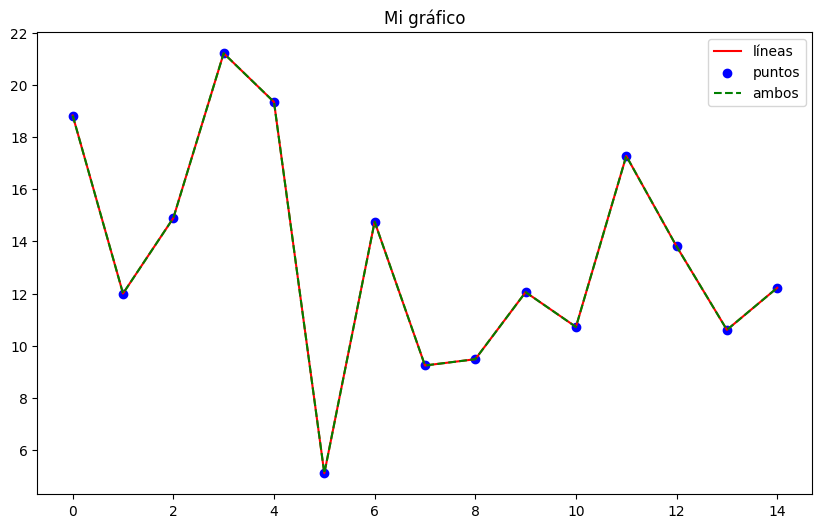

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Semilla para reproducibilidad
np.random.seed(0)

# Genera datos aleatorios de distribución normal con media=10 y desviación=5
data = np.random.normal(10, 5, 15)

# Crear el plot
plt.figure(figsize=(10, 6))

# Tres tipos de representación sobre los mismos datos:
plt.plot(data, color='red', label='líneas')          # Línea roja
plt.scatter(range(len(data)), data, color='blue', label='puntos')  # Puntos azules
plt.plot(data, 'g--', label='ambos')                 # Línea discontinua verde

# Título y leyenda
plt.title('Mi gráfico')
plt.legend(loc='upper right')
plt.show()

### 4.2 Histogramas

Muestran la **distribución de los valores** de una variable:
- Los valores se dividen en contenedores (**bins**)
- La altura de cada barra indica la **frecuencia** de ese intervalo
- El número de bins afecta mucho la forma percibida del histograma

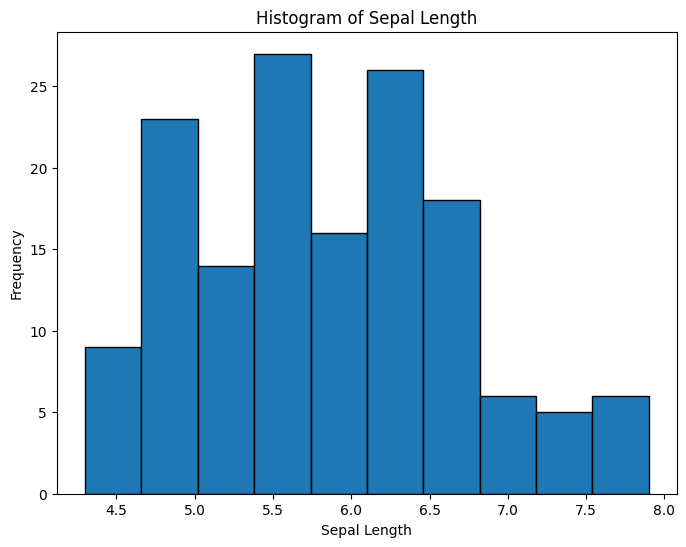

In [35]:
# Variable de interés (acceso rápido)
sepal_length = iris_df['sepal length (cm)']

# Histograma con bins por defecto
plt.figure(figsize=(8, 6))
plt.hist(sepal_length, edgecolor='black')
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

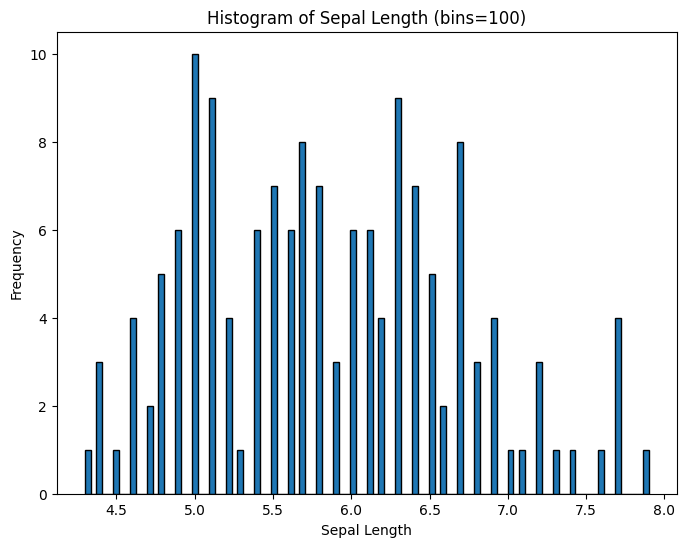

In [36]:
# Con muchos bins (bins=100) se ve la distribución con más detalle
# pero también más ruido
plt.figure(figsize=(8, 6))
plt.hist(sepal_length, edgecolor='black', bins=100)
plt.title('Histogram of Sepal Length (bins=100)')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

# Nota: con 150 observaciones y bins=100, muchos bins quedan vacíos
# → el número de bins debe ser proporcional al tamaño de la muestra

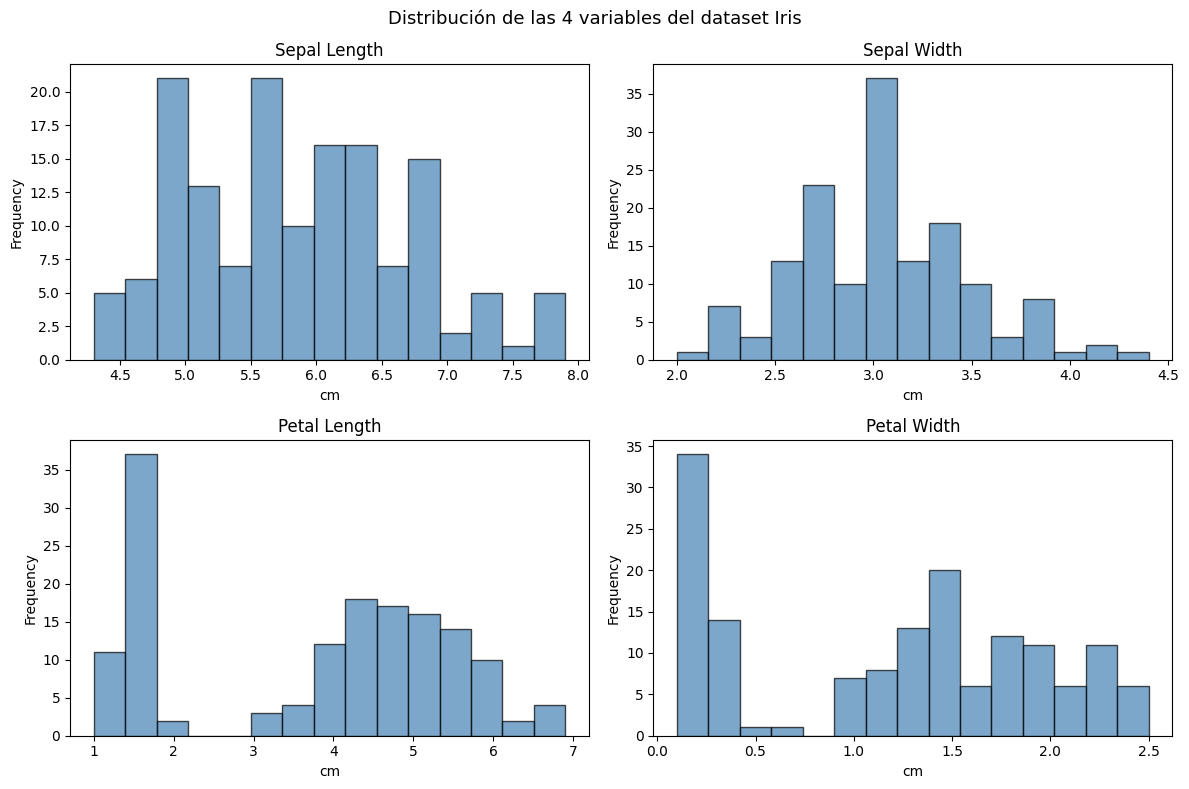

In [37]:
# Histogramas de las 4 variables en un solo gráfico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
titles = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for ax, col, title in zip(axes.flatten(), cols, titles):
    ax.hist(iris_df[col], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('cm')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribución de las 4 variables del dataset Iris', fontsize=13)
plt.tight_layout()
plt.show()

### 4.3 Estimación de Densidad (KDE)

La **densidad** es una versión suavizada del histograma.
Se calcula usando **Kernel Density Estimation (KDE)**: técnica estadística no paramétrica.
Permite ver más claramente si los datos siguen una distribución conocida (ej: normal).

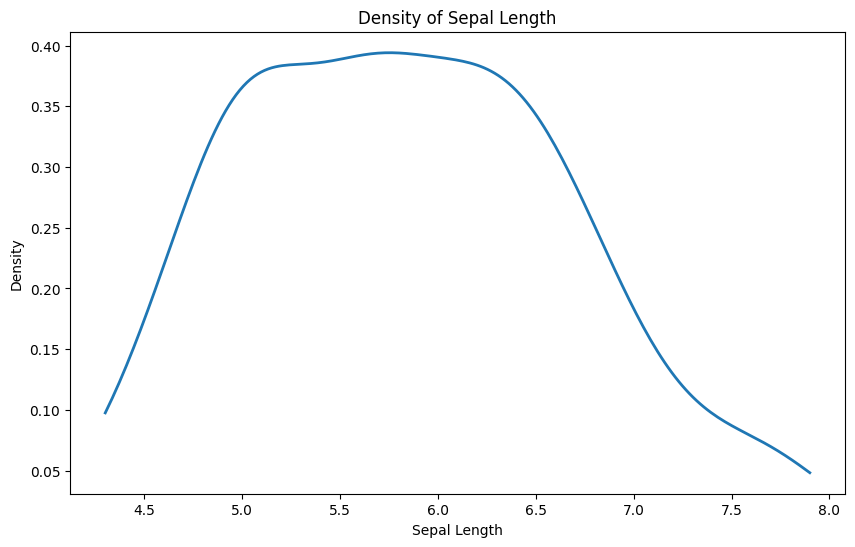

In [38]:
from scipy import stats

# Estimar la densidad con kernel gaussiano
density = stats.gaussian_kde(sepal_length)

# Generar valores equiespaciados en el rango de los datos
xs = np.linspace(sepal_length.min(), sepal_length.max(), 200)

# Evaluar la densidad en cada punto
density_values = density(xs)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(xs, density_values, linewidth=2)
plt.xlabel('Sepal Length')
plt.ylabel('Density')
plt.title('Density of Sepal Length')
plt.show()

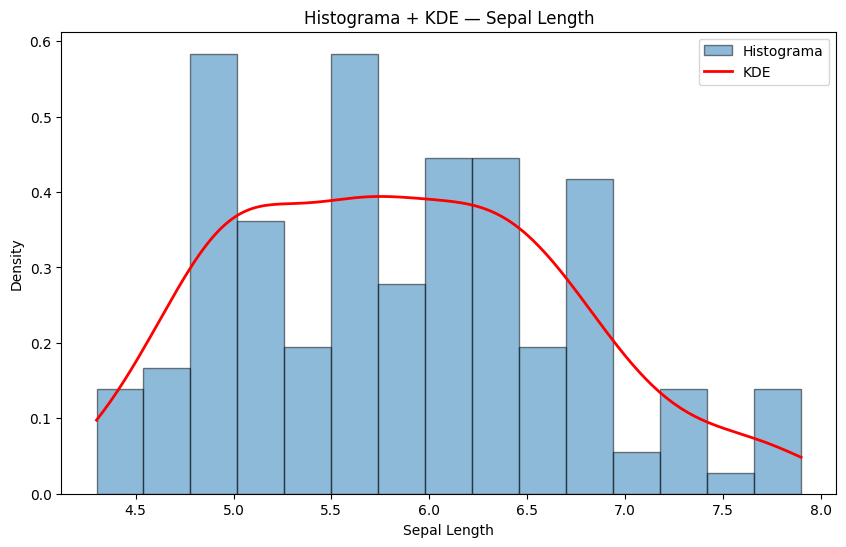

In [39]:
# Histograma + densidad juntos (normalizing hist para que sea comparable)
plt.figure(figsize=(10, 6))
plt.hist(sepal_length, bins=15, edgecolor='black', density=True, alpha=0.5, label='Histograma')
plt.plot(xs, density_values, linewidth=2, color='red', label='KDE')
plt.xlabel('Sepal Length')
plt.ylabel('Density')
plt.title('Histograma + KDE — Sepal Length')
plt.legend()
plt.show()

### 4.4 Gráficos de Torta (Pie Charts)

Representan la **frecuencia relativa** de cada categoría como una porción de un círculo.
Útiles para variables categóricas con pocas categorías.

⚠️ **No se recomiendan** mucho porque dificultan comparar proporciones similares; un gráfico de barras suele ser más claro.

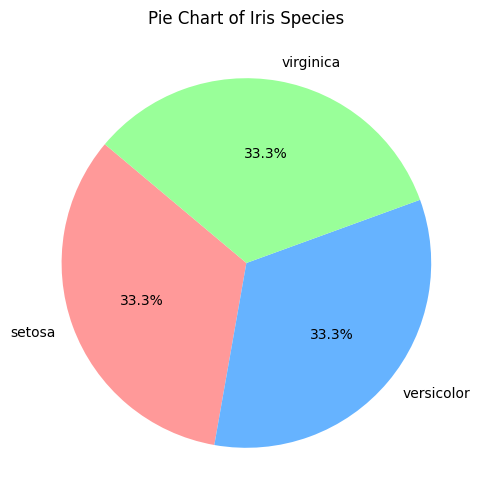

In [40]:
# Conteo de cada especie
species_counts = iris_df['species'].value_counts()
species_names  = iris_df['species'].cat.categories.tolist()

plt.figure(figsize=(8, 6))
plt.pie(
    species_counts,
    labels=species_names,
    autopct='%1.1f%%',       # Mostrar porcentaje en cada sector
    startangle=140,           # Ángulo inicial
    colors=['#ff9999', '#66b3ff', '#99ff99']  # Colores por especie
)
plt.title('Pie Chart of Iris Species')
plt.show()

### 4.5 Boxplots (Diagramas de Caja)

Se construyen a partir de los percentiles:
- **Caja**: entre Q1 (25%) y Q3 (75%)
- **Línea dentro de la caja**: mediana (Q2, 50%)
- **Altura de la caja**: IQR = Q3 − Q1 (50% central de los datos)
- **Brazos**: se extienden hasta Q1 − 1.5·IQR (inferior) y Q3 + 1.5·IQR (superior)
- **Puntos fuera de los brazos**: valores **atípicos (outliers)**

Son útiles para ver **simetría** y **outliers**, y para comparar distribuciones entre grupos.

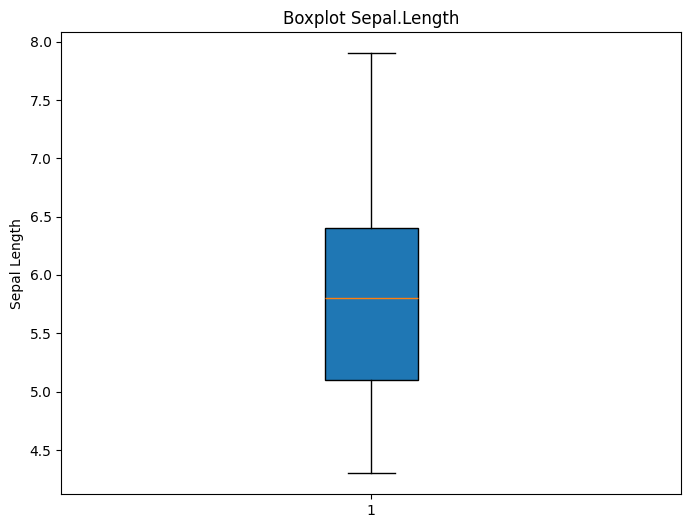

In [41]:
# Boxplot simple de sepal length
plt.figure(figsize=(8, 6))
plt.boxplot(sepal_length, patch_artist=True)  # patch_artist=True rellena la caja con color
plt.ylabel('Sepal Length')
plt.title('Boxplot Sepal.Length')
plt.show()

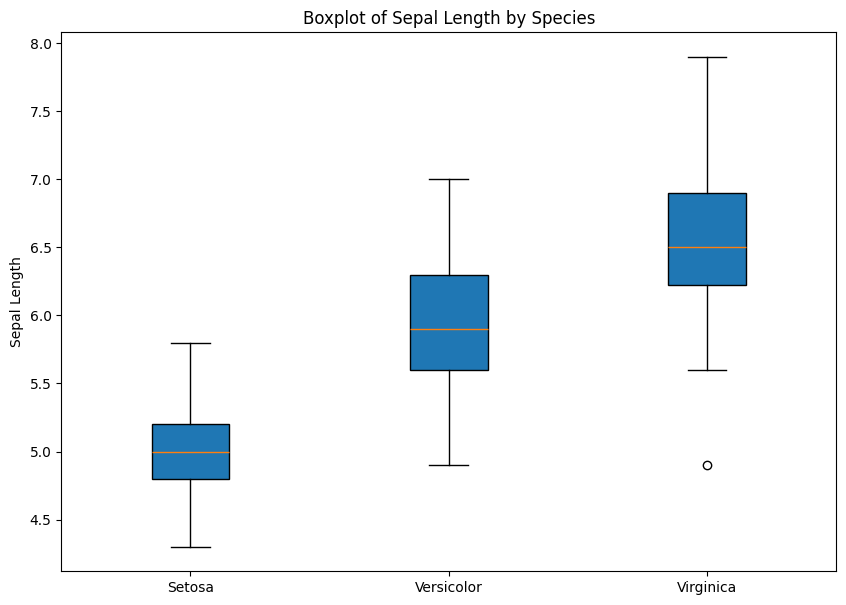

In [42]:
# Preparar los datos por especie
setosa_sample     = iris_df[iris_df['species'] == 'setosa']['sepal length (cm)']
versicolor_sample = iris_df[iris_df['species'] == 'versicolor']['sepal length (cm)']
virginica_sample  = iris_df[iris_df['species'] == 'virginica']['sepal length (cm)']

# Boxplot de sepal length separado por especie
data_to_plot = [setosa_sample, versicolor_sample, virginica_sample]
species      = ['Setosa', 'Versicolor', 'Virginica']

plt.figure(figsize=(10, 7))
plt.boxplot(data_to_plot, patch_artist=True)
plt.xticks([1, 2, 3], species)    # Etiquetas en el eje x
plt.ylabel('Sepal Length')
plt.title('Boxplot of Sepal Length by Species')
plt.show()

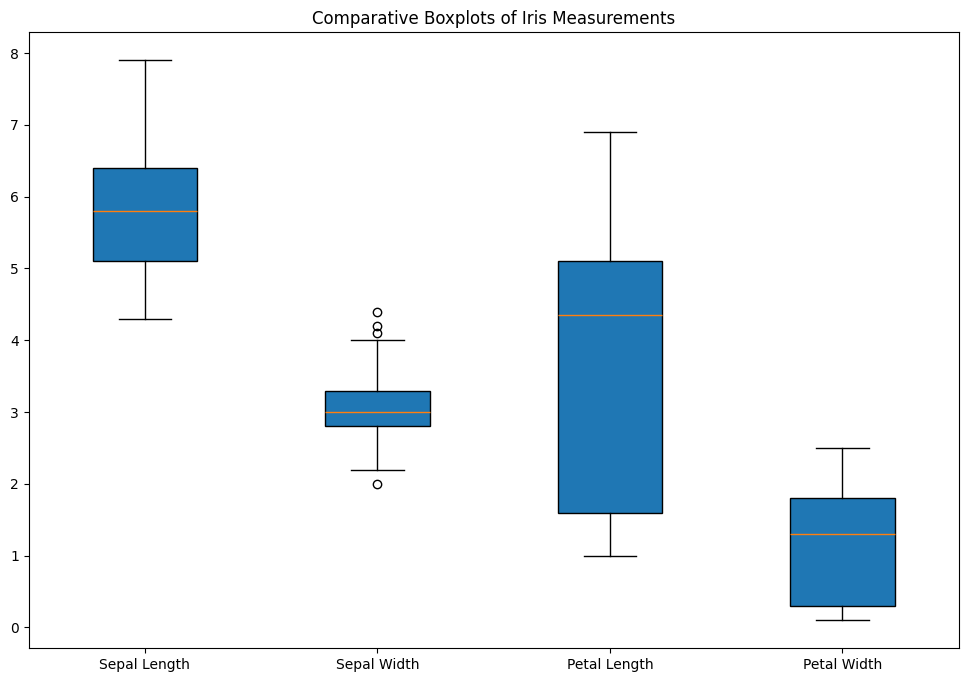

In [43]:
# Boxplot comparativo de las 4 variables en un mismo gráfico
sepal_length_sample = iris_df['sepal length (cm)']
sepal_width_sample  = iris_df['sepal width (cm)']
petal_length_sample = iris_df['petal length (cm)']
petal_width_sample  = iris_df['petal width (cm)']

data_to_plot = [sepal_length_sample, sepal_width_sample, petal_length_sample, petal_width_sample]
measurements = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

plt.figure(figsize=(12, 8))
plt.boxplot(data_to_plot, patch_artist=True)
plt.xticks([1, 2, 3, 4], measurements)
plt.title('Comparative Boxplots of Iris Measurements')
plt.show()

In [44]:
# Boxplot interactivo con Plotly (más visual, se puede hacer zoom)
import plotly.graph_objects as go

setosa_sepal_length     = iris_df[iris_df['species'] == 'setosa']['sepal length (cm)']
versicolor_sepal_length = iris_df[iris_df['species'] == 'versicolor']['sepal length (cm)']
virginica_sepal_length  = iris_df[iris_df['species'] == 'virginica']['sepal length (cm)']

# Crear figura y agregar un trace por especie
fig = go.Figure()
fig.add_trace(go.Box(y=setosa_sepal_length,     name='Setosa',     marker_color='red'))
fig.add_trace(go.Box(y=versicolor_sepal_length, name='Versicolor', marker_color='green'))
fig.add_trace(go.Box(y=virginica_sepal_length,  name='Virginica',  marker_color='blue'))

fig.update_layout(
    title='Sepal Length by Species',
    yaxis_title='Sepal Length',
    boxmode='group'    # Agrupar las cajas de distintas trazas para cada categoría
)
fig.show()

### 4.6 Diagramas de Dispersión (Scatter Plots)

Usan coordenadas cartesianas para mostrar la relación entre **dos variables numéricas**.
- Los valores de los atributos determinan la **posición** de los puntos
- Otros atributos pueden codificarse como **color, tamaño o forma**

Son ideales para visualizar **correlaciones** entre variables.

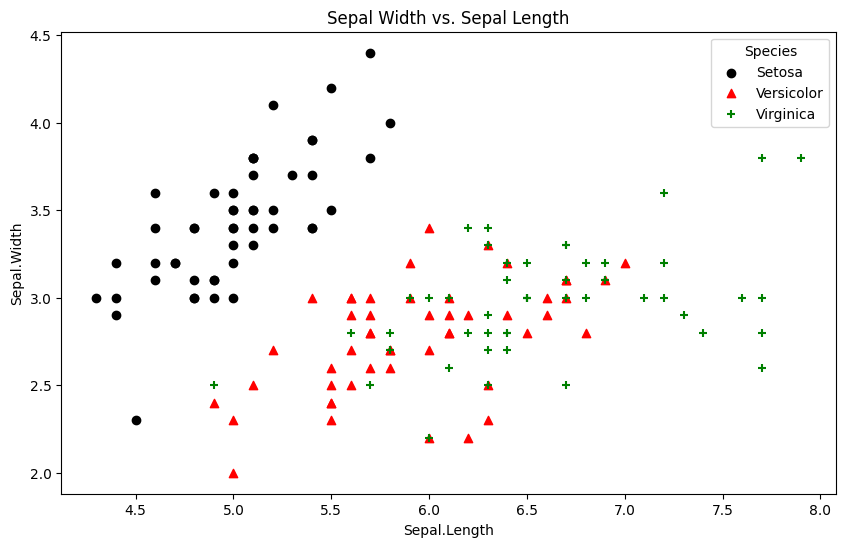

In [45]:
# Preparar los vectores por especie para el scatter
setosa_sepal_length     = iris_df[iris_df['species'] == 'setosa']['sepal length (cm)']
setosa_sepal_width      = iris_df[iris_df['species'] == 'setosa']['sepal width (cm)']
versicolor_sepal_length = iris_df[iris_df['species'] == 'versicolor']['sepal length (cm)']
versicolor_sepal_width  = iris_df[iris_df['species'] == 'versicolor']['sepal width (cm)']
virginica_sepal_length  = iris_df[iris_df['species'] == 'virginica']['sepal length (cm)']
virginica_sepal_width   = iris_df[iris_df['species'] == 'virginica']['sepal width (cm)']

# Scatter plot con Matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(setosa_sepal_length,     setosa_sepal_width,     c='black', marker='o', label='Setosa')
plt.scatter(versicolor_sepal_length, versicolor_sepal_width, c='red',   marker='^', label='Versicolor')
plt.scatter(virginica_sepal_length,  virginica_sepal_width,  c='green', marker='+', label='Virginica')
plt.legend(title='Species')
plt.xlabel('Sepal.Length')
plt.ylabel('Sepal.Width')
plt.title('Sepal Width vs. Sepal Length')
plt.show()

In [46]:
# Lo mismo usando plotly (interactivo)
import plotly.express as px

fig = px.scatter(
    iris_df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    color='species',
    color_discrete_map={'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'},
    title='Sepal Width vs. Sepal Length'
)
fig.show()

In [47]:
# Scatter matrix: todos los pares de variables en una sola figura
# No es posible hacerlo directamente en matplotlib, pero sí en plotly
df_plot = iris_df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)':  'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)':  'petal_width'
})

fig = px.scatter_matrix(
    df_plot,
    dimensions=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    color='species',
    symbol='species',
    title='Pair plot of Iris dataset'
)
fig.show()

#### Scatter 3D

Permite visualizar tres variables simultáneamente usando los ejes x, y, z.
Requiere importar el submódulo `mpl_toolkits.mplot3d`.

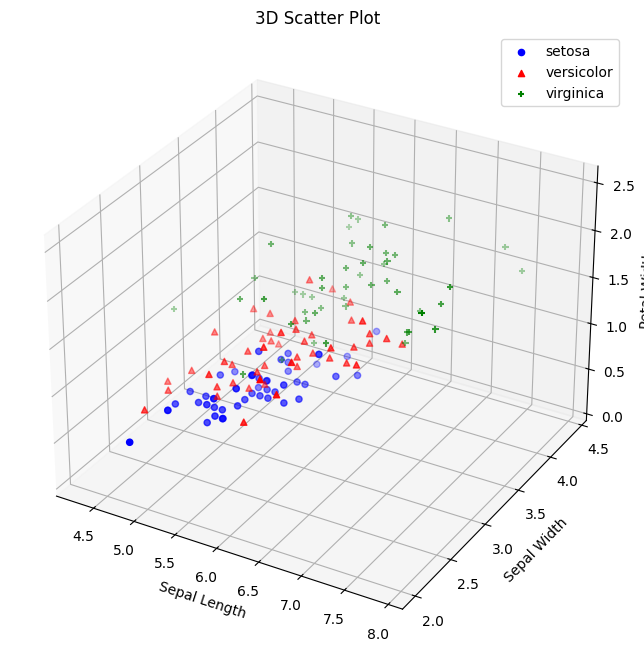

In [48]:
from mpl_toolkits.mplot3d import Axes3D

# Preparar datos 3D: largo sépalo (x), ancho sépalo (y), ancho pétalo (z)
species_list = ['setosa', 'versicolor', 'virginica']
colors_3d    = {'setosa': 'b', 'versicolor': 'r', 'virginica': 'g'}
markers_3d   = {'setosa': 'o', 'versicolor': '^', 'virginica': '+'}

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

for s in species_list:
    subset = iris_df[iris_df['species'] == s]
    x = subset['sepal length (cm)']
    y = subset['sepal width (cm)']
    z = subset['petal width (cm)']
    ax.scatter(x, y, z, c=colors_3d[s], marker=markers_3d[s], label=s)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Width')
plt.legend()
plt.title('3D Scatter Plot')
plt.show()

### 4.7 Gráficos de Coordenadas Paralelas

Alternativa para visualizar datos **multidimensionales**:
- Cada atributo tiene su propio eje vertical (paralelos entre sí)
- Cada **observación** es una línea que conecta todos los ejes
- Los valores se escalan para que todos los ejes tengan la misma altura
- Objetos similares tienden a tener **trayectorias similares**

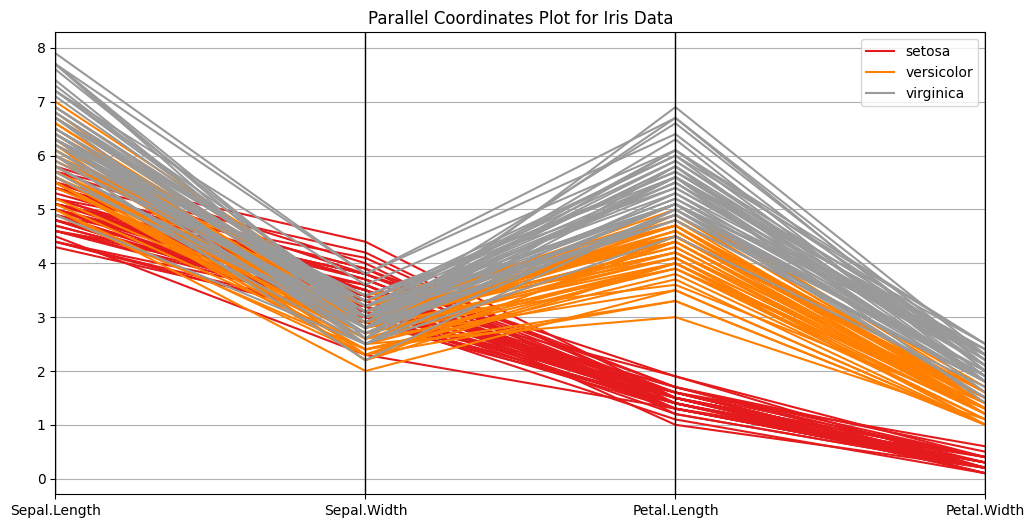

In [49]:
# Preparar DataFrame con nombres de columna simples (sin paréntesis ni espacios)
data_parallel = iris_df[[
    'sepal length (cm)', 'sepal width (cm)',
    'petal length (cm)', 'petal width (cm)', 'species'
]].copy()
data_parallel.columns = ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width', 'Species']

plt.figure(figsize=(12, 6))
pd.plotting.parallel_coordinates(
    data_parallel, 'Species',    # columna que define el color
    colormap=plt.get_cmap('Set1')
)
plt.title('Parallel Coordinates Plot for Iris Data')
plt.show()

**Interpretación**: La setosa (rojo) tiene un perfil muy distinto a las otras dos especies, especialmente en petal length y petal width. Versicolor y virginica se solapan más.

### 4.8 Gráficos de Estrellas (Radar Charts)

Cada observación se representa como una **estrella** con un eje por variable.
- Los valores de cada variable determinan el **largo de cada radio**
- Sirve para **comparar objetos** entre sí o detectar outliers
- Los valores deben estar **normalizados** (mismo rango) para que la comparación sea válida

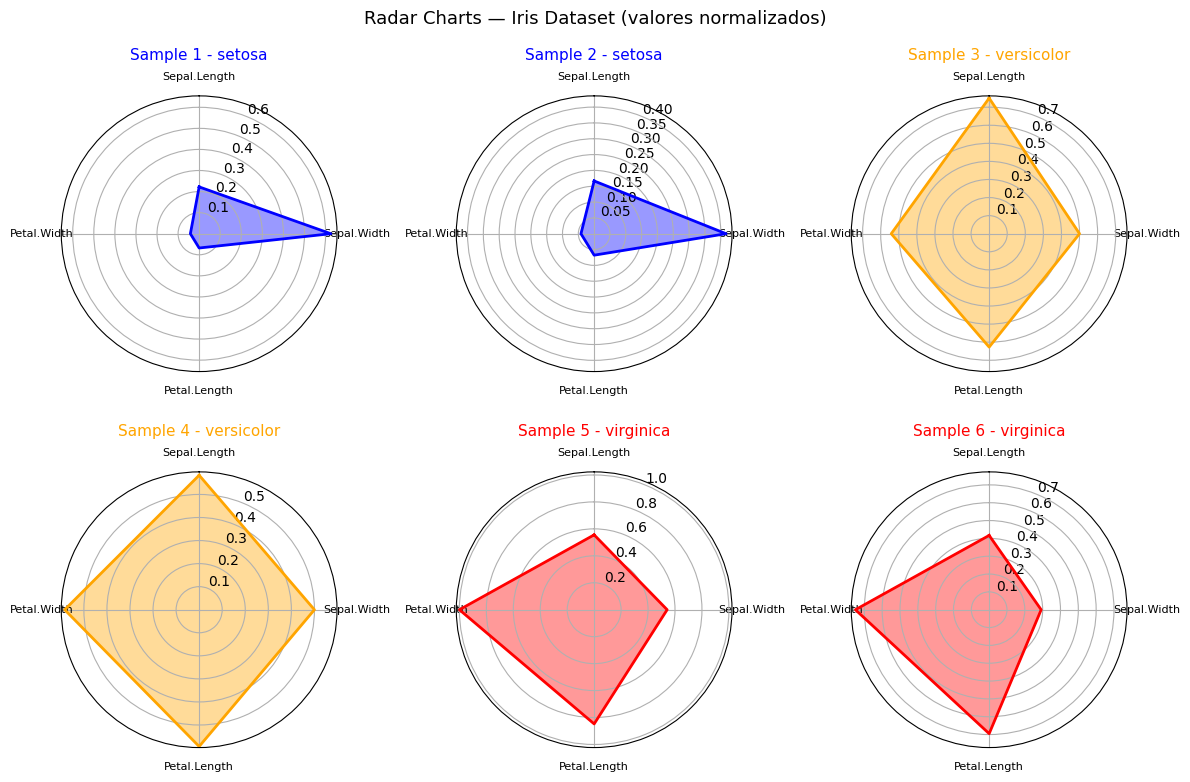

In [50]:
from sklearn.preprocessing import MinMaxScaler
from math import pi

# Normalizar los datos al rango [0, 1]
scaler = MinMaxScaler()
var_cols = ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']

data_radar = data_parallel.copy()
data_radar[var_cols] = scaler.fit_transform(data_radar[var_cols])

# Seleccionar 6 muestras (2 por especie) para el radar chart
sample = pd.concat([
    data_radar[data_radar['Species'] == 'setosa'].head(2),
    data_radar[data_radar['Species'] == 'versicolor'].head(2),
    data_radar[data_radar['Species'] == 'virginica'].head(2)
]).reset_index(drop=True)

# Calcular los ángulos de cada eje
num_vars = len(var_cols)
angles   = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles  += angles[:1]    # cerrar el polígono

# Función auxiliar para dibujar un radar chart
def make_spider(ax, row, title, color):
    values  = row[var_cols].values.flatten().tolist()
    values += values[:1]    # cerrar el polígono
    ax.set_theta_offset(pi / 2)    # el primer eje apunta arriba
    ax.set_theta_direction(-1)     # sentido horario
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(var_cols, size=8)
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
    plt.title(title, size=11, color=color, y=1.1)

# Colores por especie
colors_radar = ['blue', 'blue', 'orange', 'orange', 'red', 'red']

fig = plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(sample.iterrows()):
    ax = plt.subplot(2, 3, i + 1, polar=True)
    make_spider(ax, row, f'Sample {i+1} - {row["Species"]}', colors_radar[i])

plt.suptitle('Radar Charts — Iris Dataset (valores normalizados)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.9 Caras de Chernoff

Enfoque creado por **Herman Chernoff** (1973) basado en la capacidad humana para distinguir rostros.
- Cada **observación** se representa como una cara
- Cada **atributo** se mapea a una característica facial (boca, ojos, nariz, etc.)
- El valor del atributo determina la apariencia (tamaño, forma, curvatura)

Son útiles para comparar observaciones y detectar outliers visualmente.

**Instalación**: `pip install ChernoffFace`

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

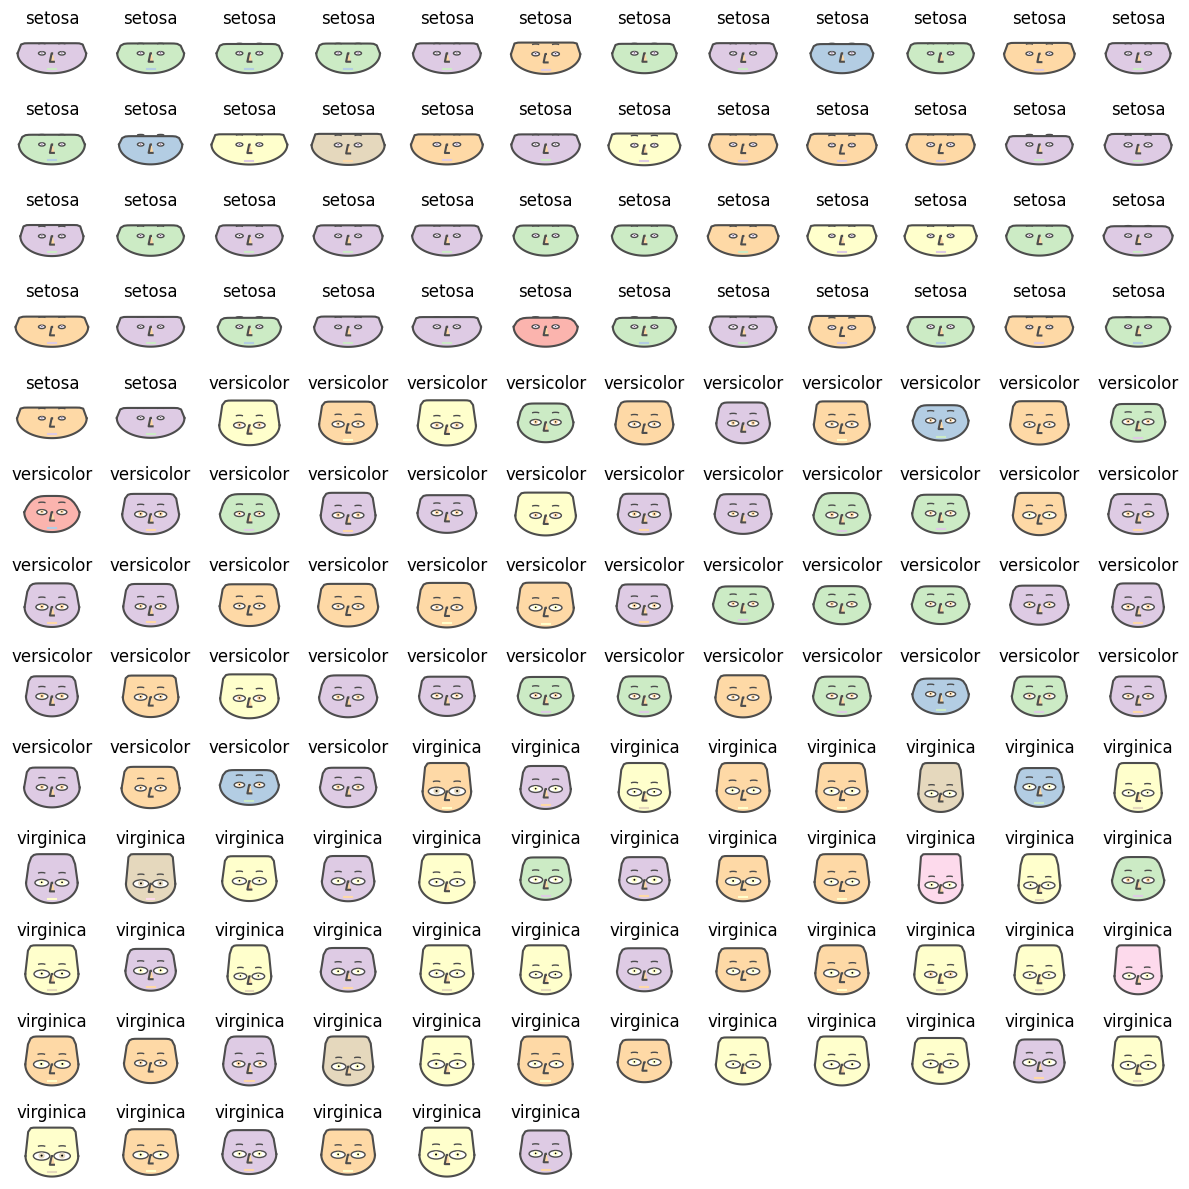

In [51]:
# Caras de Chernoff con el dataset Iris
# Requiere: pip install ChernoffFace
try:
    from ChernoffFace import chernoff_face
    from sklearn.preprocessing import MinMaxScaler

    # Normalizar los datos numéricos al rango [0, 1]
    scaler = MinMaxScaler()
    iris_normalized = scaler.fit_transform(
        iris_df[['sepal length (cm)', 'sepal width (cm)',
                 'petal length (cm)', 'petal width (cm)']]
    )

    # Nombres de especie para cada observación
    species_names = [iris.target_names[i] for i in iris.target]

    # Generar las caras de Chernoff
    fig = chernoff_face(
        data=iris_normalized,
        titles=species_names,
        color_mapper=plt.cm.Pastel1,
        figsize=(12, 12)
    )
    plt.tight_layout()
    plt.show()

except ImportError:
    print('La librería ChernoffFace no está instalada.')
    print('Ejecuta:  pip install ChernoffFace')

---
## 5. EDA Automatizado con `ydata-profiling`

`ydata-profiling` (antes llamado `pandas-profiling`) genera un **reporte HTML interactivo y completo** de forma automática sobre cualquier DataFrame, en una sola línea de código.

### ¿Qué incluye el reporte?

| Sección | Contenido |
|---|---|
| **Overview** | Número de variables, observaciones, valores faltantes, duplicados, tipos de datos |
| **Variables** | Distribución, estadísticas, histograma, valores únicos y frecuentes por columna |
| **Interactions** | Scatter plots interactivos entre pares de variables |
| **Correlations** | Matrices de Pearson, Spearman, Kendall y Cramér's V |
| **Missing values** | Mapa de calor y patrones de datos faltantes |
| **Sample** | Primeras y últimas filas del dataset |

### Instalación
```bash
pip install ydata-profiling
```

In [52]:
from ydata_profiling import ProfileReport

# Preparar el DataFrame (columnas originales, sin la columna auxiliar sepal_length_cat)
iris_profile_df = iris_df[[
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)',
    'species'
]].copy()

print('DataFrame listo para profiling:')
print(f'  Filas: {iris_profile_df.shape[0]}')
print(f'  Columnas: {iris_profile_df.shape[1]}')
iris_profile_df.head()

DataFrame listo para profiling:
  Filas: 150
  Columnas: 5


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [53]:
# Generar el reporte
# title     : título del reporte HTML
# explorative=True : activa análisis más completo (correlaciones adicionales, interacciones)
profile = ProfileReport(
    iris_profile_df,
    title='EDA Completo — Dataset Iris',
    explorative=True
)

print('✓ Reporte generado correctamente.')

✓ Reporte generado correctamente.


In [54]:
# Guardar el reporte como archivo HTML independiente
# → se puede abrir en cualquier navegador sin necesidad de Python
profile.to_file('reporte_iris_eda.html')
print('✓ Reporte guardado como: reporte_iris_eda.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<?, ?it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Reporte guardado como: reporte_iris_eda.html


In [55]:
# Visualizar el reporte embebido dentro del notebook
# Puede tardar unos segundos en renderizarse
profile.to_notebook_iframe()

---
## 6. Ejercicios propuestos

Practica lo visto en el notebook con los siguientes ejercicios:

1. Calcula el **IQR** de `petal length` para cada especie por separado usando `groupby`.
2. Grafica un **histograma** de `petal width` con 10, 20 y 40 bins en tres subgráficos.
3. Crea un **scatter plot** de `petal length` vs `petal width` coloreado por especie.
4. Genera una **tabla de contingencia** cruzando la categoría de `petal length` (3 grupos) con la especie.
5. ¿Qué par de variables tiene la **mayor correlación de Pearson**? ¿Y la menor?
6. Crea un **boxplot** de las 4 variables separado por especie usando `plotly`.
7. Ejecuta `ydata-profiling` sobre el dataset **sin** la especie y analiza las diferencias con el reporte anterior.
8. Usa la librería `sweetviz` para generar una alternativa al EDA de la librería `ydata-profiling`.
